<a href="https://colab.research.google.com/github/OsvaldoCr99/Challenge-Introducci-n-a-las-Funciones-CRUD-de-Agenda-/blob/main/Modulo_2_Proyecto_Introducci%C3%B3n_al_An%C3%A1lisis_Estad%C3%ADstico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **PROYECTO: INTRODUCCIÓN AL ANÁLISIS ESTADÍSTICO**

Una vez visto el ***Módulo 2: Fundamentos Estadísticos***, se presenta la siguiente actividad para que el alumnado pueda poner a prueba lo aprendido durante este módulo.

Dentro de la siguiente dinámica, realizar el siguiente **análisis exploratorio con aprendizaje estadístico** de cualquier dataset proveniente de la librería de ***Seaborn*** que no haya sido utilizado.

Se sugiere los siguientes puntos para llevar a cabo lo anterior:

*   Realizar un **análisis descriptivo** para comprender comportamiento de la descripción de los datos a través de resúmenes.
*   Realizar un **aprendizaje estadístico** para predecir comportamientos lineales de datos a través de la regresión lineal simple.

### 1. Cargar y Explorar el Dataset de Seaborn

Primero, importaremos las librerías necesarias y cargaremos un dataset de Seaborn. Elegiremos el dataset `tips`, que contiene datos sobre propinas recibidas en un restaurante.

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Cargar el dataset 'tips'
df = sns.load_dataset('tips')

# Mostrar las primeras filas del dataset para entender su estructura
print("Primeras 5 filas del dataset 'tips':")
display(df.head())

Primeras 5 filas del dataset 'tips':


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


### 2. Análisis Descriptivo

Realizaremos un análisis descriptivo para comprender las características principales de los datos, como la distribución de las variables numéricas y categóricas, y la presencia de valores nulos.

In [7]:
# Información general del dataset (tipos de datos, valores no nulos)
print("\nInformación del dataset:")
df.info()

# Resumen estadístico de las variables numéricas
print("\nResumen estadístico de variables numéricas:")
display(df.describe(include='number'))

# Resumen estadístico de las variables categóricas
print("\nResumen estadístico de variables categóricas:")
display(df.describe(include='category'))

# Contar valores nulos por columna
print("\nConteo de valores nulos por columna:")
display(df.isnull().sum())


Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB

Resumen estadístico de variables numéricas:


,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000



Resumen estadístico de variables categóricas:


,sex,smoker,day,time
count,244,244,244,244
unique,2,2,4,2
top,Male,No,Sat,Dinner
freq,157,151,87,176



Conteo de valores nulos por columna:


,0
total_bill,0
tip,0
sex,0
smoker,0
day,0
time,0
size,0


### 3. Aprendizaje Estadístico: Regresión Lineal Simple

Ahora, aplicaremos un modelo de regresión lineal simple para predecir el `tip` (propina) basándonos en el `total_bill` (importe total de la cuenta).

Primero, visualizaremos la relación entre estas dos variables.

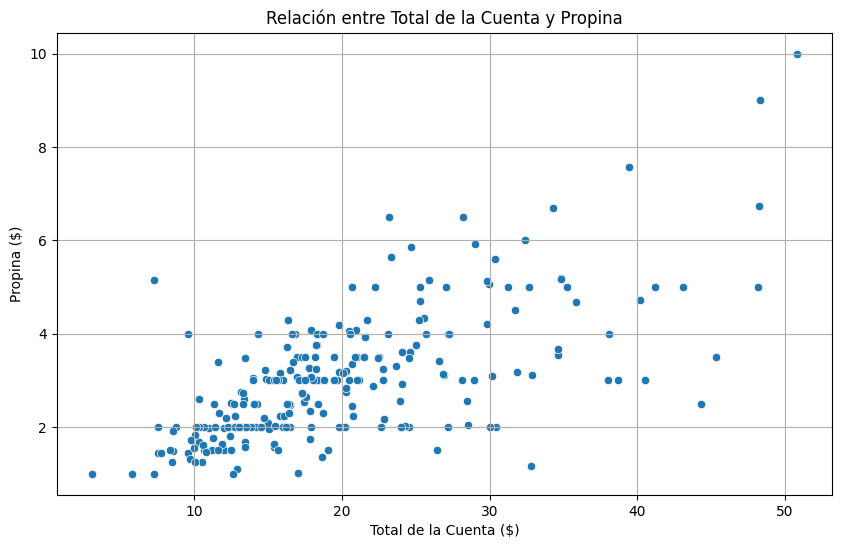

In [8]:
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Visualización de la relación entre total_bill y tip
plt.figure(figsize=(10, 6))
sns.scatterplot(x='total_bill', y='tip', data=df)
plt.title('Relación entre Total de la Cuenta y Propina')
plt.xlabel('Total de la Cuenta ($)')
plt.ylabel('Propina ($)')
plt.grid(True)
plt.show()

#### 3.1 Preparación de los Datos y Entrenamiento del Modelo

Dividiremos los datos en conjuntos de entrenamiento y prueba, y luego entrenaremos un modelo de regresión lineal.

In [9]:
# Definir variables independientes (X) y dependiente (y)
X = df[['total_bill']]
y = df['tip']

# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Inicializar y entrenar el modelo de regresión lineal
model = LinearRegression()
model.fit(X_train, y_train)

print("Modelo de regresión lineal entrenado.")
print(f"Coeficiente (pendiente): {model.coef_[0]:.2f}")
print(f"Intersección (ordenada al origen): {model.intercept_:.2f}")

Modelo de regresión lineal entrenado.
Coeficiente (pendiente): 0.11
Intersección (ordenada al origen): 0.93


#### 3.2 Evaluación del Modelo

Evaluaremos el rendimiento del modelo utilizando métricas como el Error Cuadrático Medio (MSE) y el Coeficiente de Determinación (R²).

Error Cuadrático Medio (MSE): 0.57
Coeficiente de Determinación (R²): 0.54


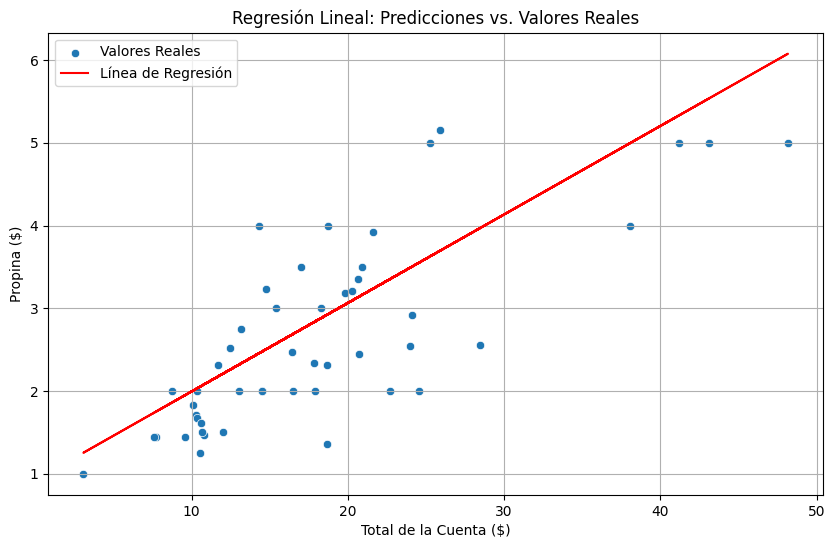

In [10]:
# Realizar predicciones en el conjunto de prueba
y_pred = model.predict(X_test)

# Evaluar el modelo
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Error Cuadrático Medio (MSE): {mse:.2f}")
print(f"Coeficiente de Determinación (R²): {r2:.2f}")

# Visualizar las predicciones frente a los valores reales
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_test['total_bill'], y=y_test, label='Valores Reales')
plt.plot(X_test['total_bill'], y_pred, color='red', label='Línea de Regresión')
plt.title('Regresión Lineal: Predicciones vs. Valores Reales')
plt.xlabel('Total de la Cuenta ($)')
plt.ylabel('Propina ($)')
plt.legend()
plt.grid(True)
plt.show()